Real-Time Credit Risk Simulation

Lightweight, real-time credit risk analysis pipeline that simulates event ingestion, processes streaming data in pandas, applies logistic regression for prediction, and generates actionable business recommendations.

Sets up the environment and imports `run_pipeline()`.

Checks if the output parquet file exists and deletes it to ensure a fresh pipeline run.

Prints a message to indicate whether the file was removed or not.


In [1]:
import sys
import pandas as pd
import threading
import time
import matplotlib.pyplot as plt

# -----------------------------
# Add project root to sys.path for module imports
# -----------------------------
root = "/Users/phillipsmith/Desktop/pythonProjects/real-time-credit-risk-simulation"
sys.path.append(root)

# -----------------------------
# Import external python modules
# -----------------------------

from pathlib import Path
from src.pipeline import run_pipeline
from src.viz.plots import Plots

# -----------------------------
# Define path to processed parquet file
# -----------------------------
file_path = Path(
    '/Users/phillipsmith/Desktop/pythonProjects/real-time-credit-risk-simulation/src/data/processed/processed_df.parquet'
)

# -----------------------------
# Delete existing parquet file for a fresh execution
# -----------------------------
if file_path.exists():
    file_path.unlink()
    print(f"Deleted existing file: {file_path}", flush=True)
else:
    print("No existing parquet file found. Continuing...", flush=True)

Deleted existing file: /Users/phillipsmith/Desktop/pythonProjects/real-time-credit-risk-simulation/src/data/processed/processed_df.parquet


Runs `run_pipeline()` in a separate thread so the notebook can monitor progress in real time.

Continuously reads the output parquet file and prints changes to the DataFrame whenever new events are added.

After the pipeline finishes, it prints the final DataFrame size.

Monitoring parquet file for updates...

Event producing has initiated.
Event consuming has initiated.

Processing is complete.

Final DataFrame shape: (45063, 8)



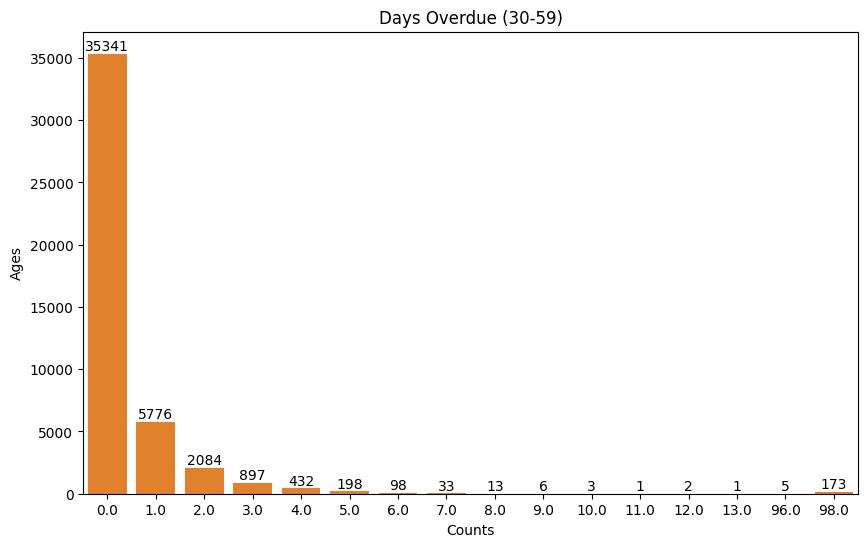

In [ ]:
# -----------------------------
# Initialize variables
# -----------------------------
previous_shape = (0, 0)
current_df = pd.DataFrame(columns=[])

# -----------------------------
# Start pipeline in a separate thread
# -----------------------------
pipeline_thread = threading.Thread(target=run_pipeline, daemon=True)
pipeline_thread.start()
print("Monitoring parquet file for updates...\n")

# -----------------------------
# Real-time monitoring loop
# -----------------------------
while pipeline_thread.is_alive():
    if file_path.exists():
        try:
            df = pd.read_parquet(file_path, engine='fastparquet')
            if not df.empty and df.shape != previous_shape:
                # execute df mods and feature engineering
                previous_shape = df.shape
        except Exception:
            pass
    time.sleep(0.05)

# -----------------------------
# Wait for pipeline thread to finish
# -----------------------------
pipeline_thread.join()

# -----------------------------
# Print final DataFrame info and graphs
# -----------------------------
if file_path.exists():
    df = pd.read_parquet(file_path, engine='fastparquet')
    print(f"Final DataFrame shape: {df.shape}\n")

    Plots.bar_graph(df, df.columns[4], x_label='Counts', y_label='Ages')
    plt.show()

else:
    print("Pipeline finished but file was not found.")